## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  
2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)

In [1]:
# Reciperamos el dataset del Titanic

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.options.mode.copy_on_write = True

df = pd.read_csv("./data/titanic.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


#### Gráficas para la presentación del TItanic

1. El titanic fue un accidente con una tasa de mortalidad alta.  
2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

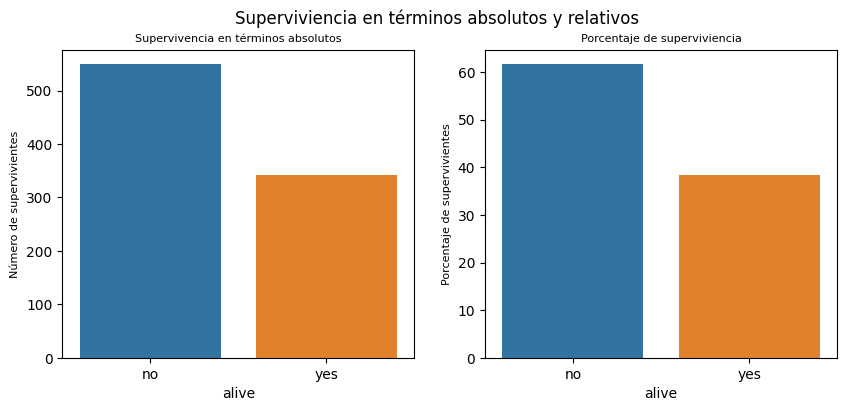

In [3]:
# 1. El titanic fue un accidente con una tasa de mortalidad alta 

fig,axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
fig.suptitle("Superviviencia en términos absolutos y relativos")

### Gráfica para superviviencia en términos absolutos
sns.countplot(x = "alive", data = df, ax = axs[0], hue = "alive", legend = False)
axs[0].set_title("Supervivencia en términos absolutos", fontsize = 8)
axs[0].set_ylabel("Número de supervivientes", fontsize = 8)

### Gráfica para porcentaje de supervivientes
valores = df.alive.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index, ax = axs[1], legend = False)
axs[1].set_title("Porcentaje de superviviencia", fontsize = 8)
axs[1].set_ylabel("Porcentaje de supervivientes", fontsize = 8)
fig;

  alive    who  proportion
0    no    man   81.785064
1    no  woman   12.021858
2    no  child    6.193078
3   yes  woman   59.941520
4   yes    man   25.730994
5   yes  child   14.327485


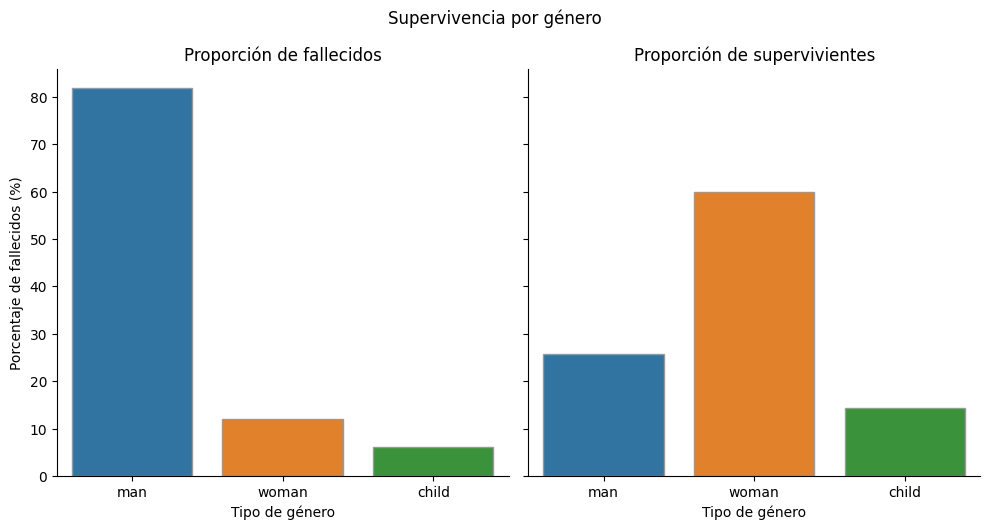

In [4]:
# 2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
### Porcentajes de superviviencia por géneros (hombres, mujeres y niños)

cat_colx = "who"
cat_coly = "alive"
frecuencias_relativas = df.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize=True)
frecuencias_relativas["proportion"] *= 100
print(frecuencias_relativas)

graphic_gen_alive = sns.catplot(x="who",
            y = "proportion",
            col="alive",
            hue = "who",
            kind="bar", 
            edgecolor=".6",
            data=frecuencias_relativas)

graphic_gen_alive.set_axis_labels("Tipo de género")
graphic_gen_alive.axes[0][0].set_title("Proporción de fallecidos") 
graphic_gen_alive.axes[0][1].set_title("Proporción de supervivientes")

graphic_gen_alive.axes[0][0].set_ylabel("Porcentaje de fallecidos (%)")
graphic_gen_alive.axes[0][1].set_ylabel("Porcentaje de supervivientes (%)")

plt.suptitle("Supervivencia por género", y=1.05) 
plt.show()

  alive   class  proportion
0    no   Third   67.759563
1    no  Second   17.668488
2    no   First   14.571949
3   yes   First   39.766082
4   yes   Third   34.795322
5   yes  Second   25.438596


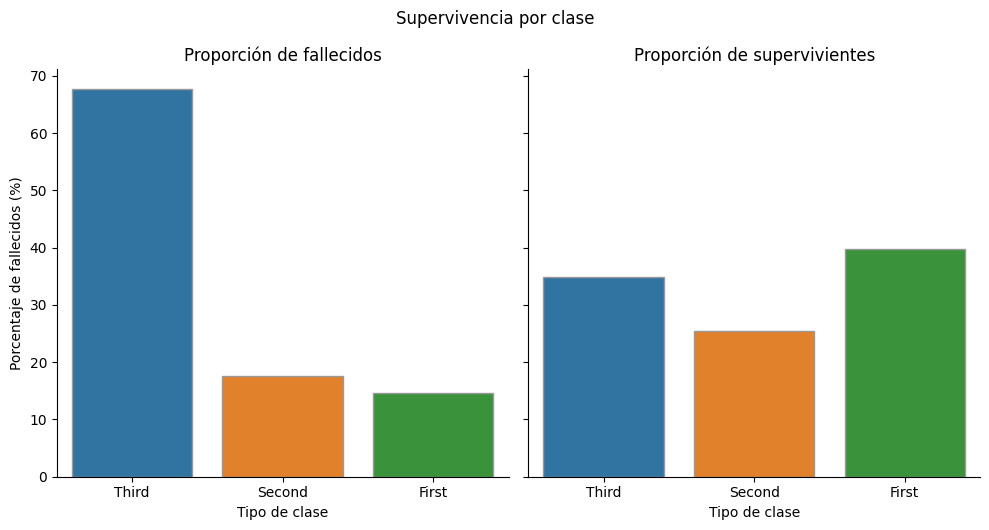

In [4]:
# 3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
### Porcentajes de superviviencia por géneros (hombres, mujeres y niños) 

cat_colx = "class"
cat_coly = "alive"
frecuencias_relativas = df.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize=True)
frecuencias_relativas["proportion"] *= 100
print(frecuencias_relativas)

graphic_class_alive = sns.catplot(x="class",
            y = "proportion",
            col="alive",
            hue = "class",
            kind="bar", 
            edgecolor=".6",
            data=frecuencias_relativas)

graphic_class_alive.set_axis_labels("Tipo de clase")

graphic_class_alive.axes[0][0].set_title("Proporción de fallecidos") 
graphic_class_alive.axes[0][1].set_title("Proporción de supervivientes")

graphic_class_alive.axes[0][0].set_ylabel("Porcentaje de fallecidos (%)")
graphic_class_alive.axes[0][1].set_ylabel("Porcentaje de supervivientes (%)")

plt.suptitle("Supervivencia por clase", y=1.05)
plt.show()

  alive    who  proportion
0    no  woman   66.000000
1    no  child   34.000000
2   yes  woman   80.708661
3   yes  child   19.291339


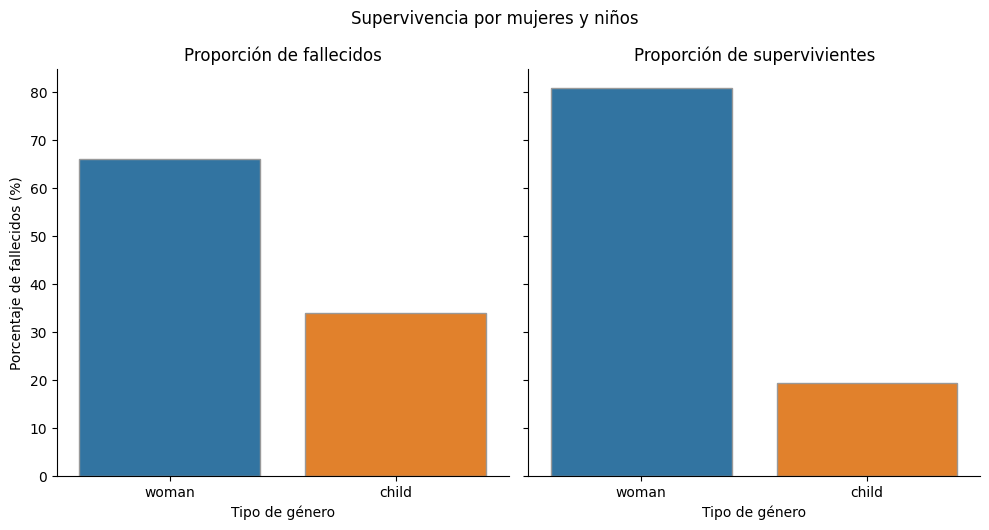

In [5]:
# 4. ...las diferencias entre tasas de supervivencia de mujeres y niños.  

df_filtrado = df[df['who'] != 'man'] # Aquí genero un dataframe donde excluyo a los hombres de la columna 'who'  

cat_colx = "who"
cat_coly = "alive"
frecuencias_relativas = df_filtrado.groupby(cat_coly, as_index=False)[cat_colx].value_counts(normalize=True)
frecuencias_relativas["proportion"] *= 100
print(frecuencias_relativas)

graphic_who_alive = sns.catplot(x="who",
            y = "proportion",
            col="alive",
            hue = "who",
            kind="bar", 
            edgecolor=".6",
            data=frecuencias_relativas)

graphic_who_alive.set_axis_labels("Tipo de género")

graphic_who_alive.axes[0][0].set_title("Proporción de fallecidos") 
graphic_who_alive.axes[0][1].set_title("Proporción de supervivientes")

graphic_who_alive.axes[0][0].set_ylabel("Porcentaje de fallecidos (%)")
graphic_who_alive.axes[0][1].set_ylabel("Porcentaje de supervivientes (%)")

plt.suptitle("Supervivencia por mujeres y niños", y=1.05) 
plt.show()

  alive  embark_town  proportion
0    no  Southampton   77.777778
1    no    Cherbourg   13.661202
2    no   Queenstown    8.561020
3   yes  Southampton   63.823529
4   yes    Cherbourg   27.352941
5   yes   Queenstown    8.823529


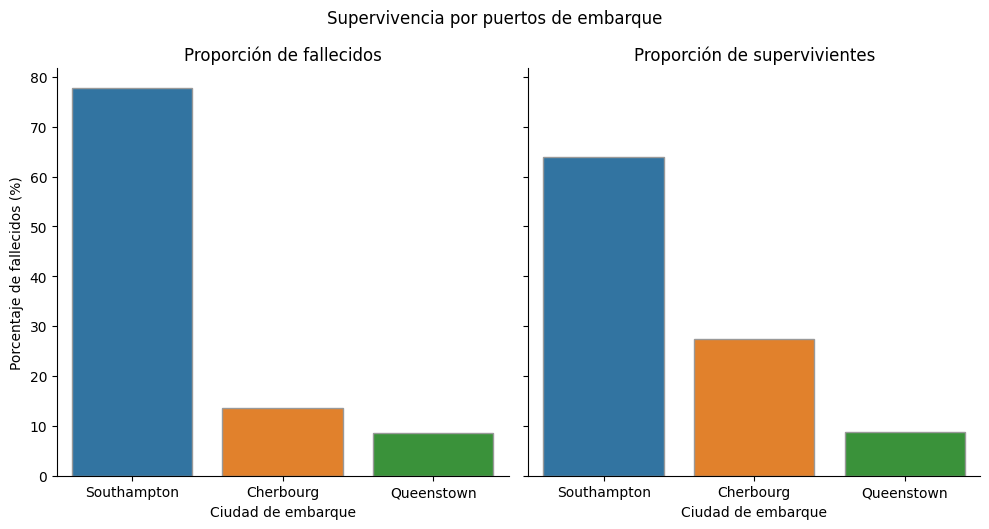

In [6]:
# 5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.

cat_colx = "embark_town"
cat_coly = "alive"
frecuencias_relativas = df.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize=True)
frecuencias_relativas["proportion"] *= 100
print(frecuencias_relativas)

graphic_emb_alive = sns.catplot(x="embark_town",
            y = "proportion",
            col="alive",
            hue = "embark_town",
            kind="bar", 
            edgecolor=".6",
            data=frecuencias_relativas)

graphic_emb_alive.set_axis_labels("Ciudad de embarque")

graphic_emb_alive.axes[0][0].set_title("Proporción de fallecidos") 
graphic_emb_alive.axes[0][1].set_title("Proporción de supervivientes")

graphic_emb_alive.axes[0][0].set_ylabel("Porcentaje de fallecidos (%)")
graphic_emb_alive.axes[0][1].set_ylabel("Porcentaje de supervivientes (%)")

plt.suptitle("Supervivencia por puertos de embarque", y=1.05) 
plt.show()

    class  embark_town  proportion
0   First  Southampton   59.345794
1   First    Cherbourg   39.719626
2   First   Queenstown    0.934579
3  Second  Southampton   89.130435
4  Second    Cherbourg    9.239130
5  Second   Queenstown    1.630435
6   Third  Southampton   71.894094
7   Third   Queenstown   14.663951
8   Third    Cherbourg   13.441955


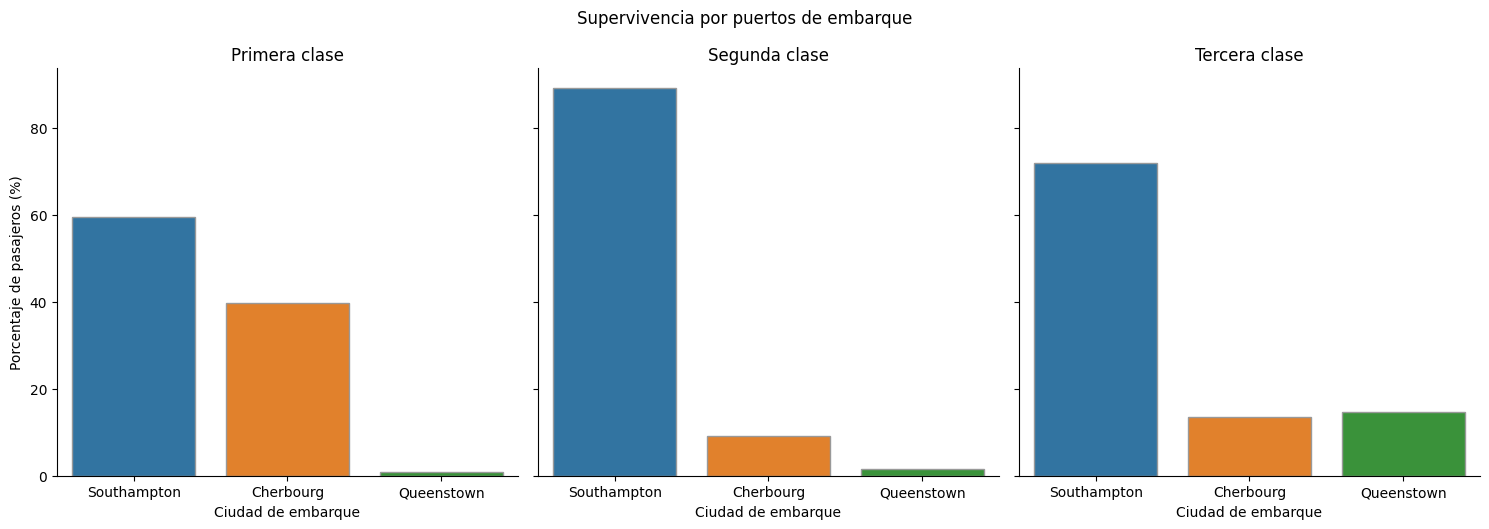

In [11]:
cat_colx = "embark_town"
cat_coly = "class"
frecuencias_relativas = df.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize=True)
frecuencias_relativas["proportion"] *= 100
print(frecuencias_relativas)

graphic_emb_class = sns.catplot(x="embark_town",
            y = "proportion",
            col="class",
            hue = "embark_town",
            kind="bar", 
            edgecolor=".6",
            data=frecuencias_relativas)

graphic_emb_class.set_axis_labels("Ciudad de embarque")

graphic_emb_class.axes[0][0].set_title("Primera clase") 
graphic_emb_class.axes[0][1].set_title("Segunda clase")
graphic_emb_class.axes[0][2].set_title("Tercera clase")

graphic_emb_class.axes[0][0].set_ylabel("Porcentaje de pasajeros (%)")

plt.suptitle("Supervivencia por puertos de embarque", y=1.05) 
plt.show()